# Notebook 21 — Hidden-Event Discovery and Signal Synthesis

Notebook 21 implements the empirical versions of Linus’s Exercises 6 and 7. Exercise 6 identifies abnormal realised and implied volatility responses that may represent hidden events or cross-channel dislocations. Exercise 7 asks whether those newly identified states contain exploratory forward information that may later support an application.

N21 does not refit flexible models, re-estimate causal structure, re-estimate known-event weights, or construct the trading strategy itself. Those upstream tasks are frozen in N16–N20. This notebook consumes N20’s ordinary, event-unaware response ratios.


## 21.1 Purpose and frozen contracts

The primary detector uses event-unaware N20 ordinary-response ratios. It does not refit models, tune on TEST, or use scheduled-event or MoF dates while detecting states.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / 'Data').is_dir():
    PROJECT_DIR = PROJECT_DIR / 'CODEWORK' / "Linus' Task Re-Do"
PROCESSED = PROJECT_DIR / 'Data' / 'processed'
FIGURES = PROJECT_DIR / 'figures'
FIGURES.mkdir(exist_ok=True)

FLEXIBLE_MODELS = ['RF', 'GB', 'MLP', 'TRANSFORMER']
PRIMARY_FAMILIES = ['FOMC', 'US Employment', 'US CPI', 'BoJ', 'JPY National CPI', 'JPY GDP']
MIN_MODEL_SUPPORT = 3
PRIMARY_ALPHA = 0.05
SENSITIVITY_ALPHAS = (0.10, 0.05, 0.01)
BLOCK_LENGTH = 5
BOOTSTRAP_REPS = 5_000
BOOTSTRAP_SEED = 21


## 21.2 N20 input loading and audits

N20's admissible ordinary background and canonical ordinary response ratio are authoritative. All four non-parametric models exist: RF, GB, MLP and Transformer.


In [2]:
panel = pd.read_csv(PROCESSED / '16_empirical_analysis_panel.csv', parse_dates=['model_day']).sort_values('model_day').reset_index(drop=True)
ratios = pd.read_csv(PROCESSED / '20_api_ordinary_response_ratios.csv', parse_dates=['model_day', 'target_model_day'])
event_mapping = pd.read_csv(PROCESSED / '18_target_specific_event_mapping.csv', parse_dates=['target_model_day'])
spot_model_day = pd.read_csv(PROCESSED / 'usdjpy_daily_model_panel.csv', parse_dates=['model_day'], usecols=['model_day','within_session_log_return']).sort_values('model_day')
required = {'model_day','target_model_day','sample_split','target','model','actual','admissible_forecast','ordinary_response_ratio','equation_eligible','background_positive','ordinary_flag'}
missing = required - set(ratios.columns)
assert not missing, f'N20 ordinary-response schema missing: {sorted(missing)}'
assert set(FLEXIBLE_MODELS).issubset(ratios['model'].unique())
assert np.allclose(ratios['ordinary_response_ratio'], ratios['response_ratio'], equal_nan=True)
assert np.allclose(ratios['ordinary_response_ratio'], ratios['ordinary_response_ratio_adm'], equal_nan=True)
assert panel['model_day'].is_unique and panel['model_day'].is_monotonic_increasing
assert spot_model_day['model_day'].is_unique and spot_model_day['model_day'].is_monotonic_increasing
panel = panel.merge(spot_model_day, on='model_day', how='left', validate='one_to_one')
panel['usdjpy_model_day_return'] = pd.to_numeric(panel['within_session_log_return'], errors='coerce')
panel['abs_usdjpy_model_day_return'] = panel['usdjpy_model_day_return'].abs()
spot_q_alignment = panel['squared_return'].notna() & panel['usdjpy_model_day_return'].notna()
assert spot_q_alignment.any()
assert np.allclose(panel.loc[spot_q_alignment,'squared_return'], panel.loc[spot_q_alignment,'usdjpy_model_day_return'].pow(2), rtol=1e-12, atol=1e-15)
spot_return_provenance = 'N15 usdjpy_daily_model_panel.within_session_log_return: signed sum of within-session USD/JPY hourly log returns on the canonical [D-1 17:00 NY, D 17:00 NY) model day; N16 squared_return/Q_t is its square.'
spot_return_provenance_verified = bool(spot_q_alignment.any())
panel['R'] = pd.to_numeric(panel['realised_variance_ann_252'], errors='coerce')
panel['I'] = pd.to_numeric(panel['iv_model_var'], errors='coerce')
panel['canonical_index'] = np.arange(len(panel))
panel['previous_model_day'] = panel['model_day'].shift(1)
panel['next_model_day'] = panel['model_day'].shift(-1)
panel['previous_sample_split'] = panel['sample_split'].shift(1)
assert panel['previous_model_day'].equals(panel['model_day'].shift(1))
n20_contract_audit = pd.DataFrame([{'n20_loaded': True, 'ordinary_ratio': 'actual / admissible_forecast', 'models': ' | '.join(FLEXIBLE_MODELS), 'min_model_support': MIN_MODEL_SUPPORT, 'spot_return_provenance': spot_return_provenance}])
display(n20_contract_audit)


,n20_loaded,ordinary_ratio,models,min_model_support,spot_return_provenance
0,True,actual / admissible_forecast,RF | GB | MLP | TRANSFORMER,3,N15 usdjpy_daily_model_panel.within_session_lo...


## 21.3 Ordinary response weights and signed log weights

For $Y\in\{R,I\}$ and flexible model $m$, $\widehat F^{Y,\mathrm{adm}}_{m,t}$ is the frozen ordinary event-unaware background forecast (meaning the days where there are events are not removed from the dataset). The response weight is

$$
\omega^Y_{m,t}=\frac{Y_t}{\widehat F^{Y,\mathrm{adm}}_{m,t}}.
$$

$\omega=1$ means the observation equals its ordinary background; $\omega>1$ means it is above background; and $0<\omega<1$ means it is below background. One is a neutral multiplicative benchmark, not a significance boundary. The actual $\omega$ values are retained because they provide the direct economic response magnitude.

The detector uses the signed transform $$L^Y_{m,t}=\log\omega^Y_{m,t}.$$ Hence $\omega=1\iff L=0$, while values above and below background retain opposite signs. We do not use $|\log\omega|$: very small and very large response weights can both be unusual while representing different economic directions.


## 21.4–21.6 Positivity, $\widehat F$ versus $\widehat G$, percentiles, and empirical tails

Because $\log\omega$ requires $\omega>0$, positivity is audited before scoring. Non-positive observations, if present, are retained in the audit but are not repaired by clipping, absolute values, or arbitrary epsilons; they are simply ineligible for a log score.

$\widehat F$ is a forecast. By contrast, $\widehat G_m^{Y,\mathrm{VAL}}$ is not a forecasting model: it is the empirical CDF of eligible ordinary VALIDATION signed log weights,

$$
\widehat G_m^{Y,\mathrm{VAL}}(l)=\frac1N\sum_{j\in\mathcal V_Y}\mathbf1(L^Y_{m,j}\le l).
$$

$\mathcal V_Y$ is the ordinary validation reference set.

Using $G$ avoids colliding with the forecast notation $F$. The hat means the unknown distribution is estimated from the finite ordinary VALIDATION sample. Thus $U^Y_{m,t}=\widehat G_m^{Y,\mathrm{VAL}}(L^Y_{m,t})$ is today’s empirical percentile: $U=0.98$ means roughly 98% of reference log weights were no larger. Near one is unusually high, near zero unusually low, and near 0.5 central.

$$p^{Y,emp}_{m,t}=\min[1,2\min(U^Y_{m,t},1-U^Y_{m,t})].$$

For $U=0.99$ or $0.01$, this score is approximately 0.02, but the tail direction differs. The score answers how unusual, $U$ identifies the tail, and $\omega$ gives the multiplicative response. It is an empirical two-sided tail score, not a classical parametric p-value.


In [3]:
def bool_flag(s):
    return s.fillna(False).astype(bool) if s.dtype == bool else s.astype(str).str.strip().str.lower().isin(['true', '1'])

def empirical_cdf(values, reference):
    return np.searchsorted(reference, np.asarray(values, float), side='right') / len(reference)

def empirical_two_sided_tail(u):
    return np.minimum(1.0, 2.0 * np.minimum(u, 1.0 - u))

model_scores = ratios.loc[ratios['model'].isin(FLEXIBLE_MODELS)].copy()
model_scores['omega'] = pd.to_numeric(model_scores['ordinary_response_ratio'], errors='coerce')
model_scores['ordinary_reference'] = bool_flag(model_scores['ordinary_flag'])
model_scores['finite_omega'] = np.isfinite(model_scores['omega'])
model_scores['positive_omega'] = model_scores['finite_omega'] & model_scores['omega'].gt(0)
model_scores['log_eligible'] = model_scores['positive_omega']
model_scores['log_omega'] = np.where(model_scores['log_eligible'], np.log(model_scores['omega']), np.nan)

positivity_audit = model_scores.groupby(['sample_split','target','model'], as_index=False).agg(
    total_response_ratios=('omega','size'), finite_response_ratios=('finite_omega','sum'),
    strictly_positive_ratios=('positive_omega','sum'), zero_ratios=('omega', lambda x: int((x == 0).sum())),
    negative_ratios=('omega', lambda x: int((x < 0).sum())), log_eligible_ratios=('log_eligible','sum')
)
cdf_rows, scored_parts = [], []
for (target, model), group in model_scores.groupby(['target','model'], sort=True):
    reference = group.loc[group['sample_split'].eq('validation') & group['ordinary_reference'] & group['log_eligible'], 'log_omega'].sort_values().to_numpy(float)
    assert len(reference) > 0, f'No ordinary VALIDATION log weights for {target}/{model}'
    part = group.copy()
    eligible = part['log_eligible']
    part.loc[eligible, 'U'] = empirical_cdf(part.loc[eligible, 'log_omega'], reference)
    part.loc[eligible, 'p_emp'] = empirical_two_sided_tail(part.loc[eligible, 'U'])
    scored_parts.append(part)
    cdf_rows.append({'target': target, 'model': model, 'reference_split': 'VALIDATION_ORDINARY_ONLY', 'n_reference': len(reference), 'min_log_omega': float(reference.min()), 'max_log_omega': float(reference.max())})
model_scores = pd.concat(scored_parts, ignore_index=True)
empirical_cdf_reference_summary = pd.DataFrame(cdf_rows)
ecdf_reference_audit = model_scores.groupby(['target','model'], as_index=False).apply(lambda g: pd.Series({'split':'VALIDATION','n_validation_total':int(g['sample_split'].eq('validation').sum()),'n_validation_ordinary':int((g['sample_split'].eq('validation') & g['ordinary_reference']).sum()),'n_validation_log_eligible':int((g['sample_split'].eq('validation') & g['log_eligible']).sum()),'n_ecdf_reference':int((g['sample_split'].eq('validation') & g['ordinary_reference'] & g['log_eligible']).sum())}), include_groups=False).reset_index(drop=True)
assert not model_scores.loc[~model_scores['log_eligible'], 'log_omega'].notna().any()
display(positivity_audit)
display(empirical_cdf_reference_summary)
display(ecdf_reference_audit)


,sample_split,target,model,total_response_ratios,finite_response_ratios,strictly_positive_ratios,zero_ratios,negative_ratios,log_eligible_ratios
0,test,I,GB,1208,1208,1208,0,0,1208
1,test,I,MLP,1156,1156,1156,0,0,1156
2,test,I,RF,1208,1208,1208,0,0,1208
3,test,I,TRANSFORMER,1142,1142,1142,0,0,1142
4,test,R,GB,1169,1169,1169,0,0,1169
5,test,R,MLP,1182,1182,1182,0,0,1182
6,test,R,RF,1182,1182,1182,0,0,1182
7,test,R,TRANSFORMER,1182,1182,1182,0,0,1182
8,validation,I,GB,1209,1209,1209,0,0,1209
9,validation,I,MLP,1155,1155,1155,0,0,1155


,target,model,reference_split,n_reference,min_log_omega,max_log_omega
0,I,GB,VALIDATION_ORDINARY_ONLY,945,-2.690649,2.044556
1,I,MLP,VALIDATION_ORDINARY_ONLY,899,-1.918102,2.139603
2,I,RF,VALIDATION_ORDINARY_ONLY,945,-2.070892,2.451518
3,I,TRANSFORMER,VALIDATION_ORDINARY_ONLY,888,-1.456458,2.188744
4,R,GB,VALIDATION_ORDINARY_ONLY,907,-2.992982,1.781033
5,R,MLP,VALIDATION_ORDINARY_ONLY,919,-2.304157,3.109433
6,R,RF,VALIDATION_ORDINARY_ONLY,919,-2.570957,3.198355
7,R,TRANSFORMER,VALIDATION_ORDINARY_ONLY,919,-2.336914,3.077113


,target,model,split,n_validation_total,n_validation_ordinary,n_validation_log_eligible,n_ecdf_reference
0,I,GB,VALIDATION,1209,945,1209,945
1,I,MLP,VALIDATION,1155,899,1155,899
2,I,RF,VALIDATION,1209,945,1209,945
3,I,TRANSFORMER,VALIDATION,1143,888,1143,888
4,R,GB,VALIDATION,1168,907,1168,907
5,R,MLP,VALIDATION,1181,919,1181,919
6,R,RF,VALIDATION,1181,919,1181,919
7,R,TRANSFORMER,VALIDATION,1181,919,1181,919


## 21.7–21.9 Four-model consensus, ordinary-VALIDATION thresholds, and four states

RF, GB, MLP, and Transformer each provide a model-specific empirical tail assessment. With at least $MIN\_MODEL\_SUPPORT=3$ valid models, the consensus is

$$P_t^Y=\operatorname{median}_m p_{m,t}^{Y,emp}.$$

The median is robust to one model family and we also retain $\widetilde\omega_t^Y=\operatorname{median}_m\omega_{m,t}^Y$ and $\widetilde L_t^Y=\operatorname{median}_m L_{m,t}^Y$ for magnitude and direction. Because the median tail statistic is not assumed Uniform$(0,1)$, it receives its own ordinary-VALIDATION calibration:

$$c_Y(\alpha)=Q_{\alpha}^{\mathrm{ordinary\ VAL}}(P^Y).$$

Primary $\alpha=0.05$ and 0.10/0.01 sensitivities are fixed before TEST. Both model CDFs and consensus thresholds use ordinary VALIDATION only; all eligible TEST days are then scored blindly, and known-event labels are attached afterwards. $R_t$ is paired with $I_{t-1}$ from the immediately previous canonical model-day, not calendar date minus one day.

| R channel | Previous I channel | Primary state |
| --- | --- | --- |
| ordinary | ordinary | NONE |
| abnormal | ordinary | REALISED_ONLY |
| ordinary | abnormal | IMPLIED_ONLY |
| abnormal | abnormal | JOINT |

JOINT preserves simultaneous abnormalities that could cancel in the historical $D_t=Z_R(t)-Z_I(t-1)$ representation. Direction remains separate: signed consensus log weights label ABOVE_BACKGROUND, BELOW_BACKGROUND, or AT_BACKGROUND.


In [4]:
def direction(log_value):
    if log_value > 0: return 'ABOVE_BACKGROUND'
    if log_value < 0: return 'BELOW_BACKGROUND'
    return 'AT_BACKGROUND'

consensus_rows = []
for (day, split, target), group in model_scores.groupby(['model_day','sample_split','target'], sort=True):
    valid = group.loc[group['log_eligible'] & group['p_emp'].notna()].copy()
    if len(valid) < MIN_MODEL_SUPPORT:
        continue
    median_log = float(valid['log_omega'].median())
    signs = np.sign(valid['log_omega'])
    consensus_rows.append({'model_day': day, 'sample_split': split, 'target': target, 'ordinary_reference': bool(valid['ordinary_reference'].all()), 'n_model_support': int(len(valid)), 'consensus_tail_p': float(valid['p_emp'].median()), 'omega_consensus': float(valid['omega'].median()), 'log_omega_consensus': median_log, 'median_U': float(valid['U'].median()), 'min_U': float(valid['U'].min()), 'max_U': float(valid['U'].max()), 'above_below_agreement_count': int(max((signs > 0).sum(), (signs < 0).sum(), (signs == 0).sum())), 'direction': direction(median_log)})
consensus_scores = pd.DataFrame(consensus_rows)
assert consensus_scores['n_model_support'].ge(MIN_MODEL_SUPPORT).all()

threshold_rows = []
for target in ['R','I']:
    values = consensus_scores.loc[(consensus_scores['target'].eq(target)) & (consensus_scores['sample_split'].eq('validation')) & consensus_scores['ordinary_reference'], 'consensus_tail_p']
    assert len(values) > 0
    for alpha in SENSITIVITY_ALPHAS:
        threshold_rows.append({'target': target, 'alpha': alpha, 'threshold': float(values.quantile(alpha)), 'reference_split': 'VALIDATION_ORDINARY_ONLY', 'ordinary_reference': True, 'n_reference': int(len(values))})
consensus_tail_thresholds = pd.DataFrame(threshold_rows)
consensus_threshold_reference_audit = consensus_scores.loc[consensus_scores['sample_split'].eq('validation')].groupby('target',as_index=False).agg(n_validation_consensus_total=('model_day','size'),n_validation_consensus_ordinary=('ordinary_reference','sum'))
consensus_threshold_reference_audit['n_threshold_reference'] = consensus_threshold_reference_audit['target'].map(consensus_tail_thresholds.groupby('target')['n_reference'].first())
for alpha, label in [(0.10,'c_10'),(0.05,'c_05'),(0.01,'c_01')]: consensus_threshold_reference_audit[label] = consensus_threshold_reference_audit['target'].map(consensus_tail_thresholds.loc[consensus_tail_thresholds['alpha'].eq(alpha)].set_index('target')['threshold'])
assert consensus_tail_thresholds['reference_split'].eq('VALIDATION_ORDINARY_ONLY').all() and consensus_tail_thresholds['ordinary_reference'].all()
threshold_lookup = consensus_tail_thresholds.set_index(['target','alpha'])['threshold']

r_scores = consensus_scores.loc[consensus_scores['target'].eq('R')].rename(columns={'consensus_tail_p':'consensus_tail_p_R','omega_consensus':'omega_R_consensus','log_omega_consensus':'log_omega_R_consensus','median_U':'median_U_R','min_U':'min_U_R','max_U':'max_U_R','n_model_support':'n_models_R','direction':'R_direction','above_below_agreement_count':'R_agreement'})
i_scores = consensus_scores.loc[consensus_scores['target'].eq('I')].rename(columns={'model_day':'previous_model_day','sample_split':'previous_sample_split','consensus_tail_p':'consensus_tail_p_I_prev','omega_consensus':'omega_I_prev_consensus','log_omega_consensus':'log_omega_I_prev_consensus','median_U':'median_U_I_prev','min_U':'min_U_I_prev','max_U':'max_U_I_prev','n_model_support':'n_models_I','direction':'I_direction','above_below_agreement_count':'I_agreement'})
primary_pairs = panel[['model_day','previous_model_day','sample_split','previous_sample_split','canonical_index']].merge(r_scores.drop(columns='target'), on=['model_day','sample_split'], how='inner').merge(i_scores.drop(columns='target'), on=['previous_model_day','previous_sample_split'], how='inner')
primary_pairs = primary_pairs.loc[primary_pairs['sample_split'].eq(primary_pairs['previous_sample_split'])].copy()
primary_pairs['R_threshold_05'] = threshold_lookup.loc[('R', PRIMARY_ALPHA)]
primary_pairs['I_threshold_05'] = threshold_lookup.loc[('I', PRIMARY_ALPHA)]
primary_pairs['R_abnormal'] = primary_pairs['consensus_tail_p_R'].le(primary_pairs['R_threshold_05'])
primary_pairs['I_abnormal_prev'] = primary_pairs['consensus_tail_p_I_prev'].le(primary_pairs['I_threshold_05'])
primary_pairs['primary_state'] = np.select([primary_pairs['R_abnormal'] & ~primary_pairs['I_abnormal_prev'], ~primary_pairs['R_abnormal'] & primary_pairs['I_abnormal_prev'], primary_pairs['R_abnormal'] & primary_pairs['I_abnormal_prev']], ['REALISED_ONLY','IMPLIED_ONLY','JOINT'], default='NONE')
primary_pairs['is_candidate'] = primary_pairs['primary_state'].ne('NONE')
primary_test_scores = primary_pairs.loc[primary_pairs['sample_split'].eq('test')].copy()
display(consensus_tail_thresholds)


,target,alpha,threshold,reference_split,ordinary_reference,n_reference
0,R,0.10,0.104869,VALIDATION_ORDINARY_ONLY,True,919
1,R,0.05,0.051034,VALIDATION_ORDINARY_ONLY,True,919
2,R,0.01,0.011985,VALIDATION_ORDINARY_ONLY,True,919
3,I,0.10,0.134501,VALIDATION_ORDINARY_ONLY,True,899
4,I,0.05,0.062683,VALIDATION_ORDINARY_ONLY,True,899
5,I,0.01,0.012255,VALIDATION_ORDINARY_ONLY,True,899


## 21.10–21.15 Detect first, annotate after, episodes, and diagnostics

The detector is not told FOMC, Employment, CPI, BoJ, JPY CPI, JPY GDP, or MoF dates before classification. First `primary_state` is assigned from the frozen response reference. A candidate is any non-NONE state. Only then are target-specific known-event labels attached; a strict hidden candidate is a candidate with no canonical six-family event on the $R_t/I_{t-1}$ pair. A detected FOMC response therefore remains a genuine abnormal observation but is not labelled hidden.

Month-end is retained only as an N18-consistent calendar annotation, not as a seventh event family, calibration input, or exclusion rule. Adjacent strict candidates become one episode only when they share the same state. The peak is selected by the smallest active-channel tail score,

$$p_t^{peak}=\min\{P_R(t),P_I(t-1)\}_{\mathrm{active}},$$

with the earliest day resolving a tie. The 10%, 5%, and 1% tables are sensitivity checks, not post-TEST competing specifications. Calibration transfer reports $\Delta_Y=\widehat p_Y^{TEST}-\widehat p_Y^{VAL}$ with a five-model-day chronological moving-block interval; it is a distribution-shift diagnostic, not a reason to recalibrate TEST.


In [22]:
def family_map(target):
    subset = event_mapping.loc[event_mapping['target'].eq(target) & event_mapping['event_label'].isin(PRIMARY_FAMILIES)]
    return subset.groupby('target_model_day')['event_label'].agg(lambda x: ' | '.join(sorted(set(x)))).to_dict()

r_family_map, i_family_map = family_map('R'), family_map('I')
primary_pairs['R_event_families'] = primary_pairs['model_day'].map(r_family_map).fillna('')
primary_pairs['I_prev_event_families'] = primary_pairs['previous_model_day'].map(i_family_map).fillna('')
primary_pairs['known_primary_event_pair'] = primary_pairs['R_event_families'].ne('') | primary_pairs['I_prev_event_families'].ne('')
months = panel['model_day'].dt.to_period('M')
month_end_days = set(panel.loc[panel['model_day'].eq(panel.groupby(months)['model_day'].transform('max')), 'model_day'])
primary_pairs['is_month_end_t'] = primary_pairs['model_day'].isin(month_end_days)
primary_pairs['is_month_end_prev'] = primary_pairs['previous_model_day'].isin(month_end_days)
primary_pairs['month_end_pair'] = primary_pairs['is_month_end_t'] | primary_pairs['is_month_end_prev']
primary_pairs['strict_hidden_candidate'] = primary_pairs['is_candidate'] & ~primary_pairs['known_primary_event_pair']
primary_test_scores = primary_pairs.loc[primary_pairs['sample_split'].eq('test')].copy()
primary_all_candidate_days = primary_test_scores.loc[primary_test_scores['is_candidate']].sort_values('canonical_index').copy()
primary_candidate_days = primary_test_scores.loc[primary_test_scores['strict_hidden_candidate']].sort_values('canonical_index').copy()

def build_episodes(frame, state_col, strict_col, prefix):
    days = frame.loc[frame[strict_col]].sort_values('canonical_index').copy()
    active = np.where(days['R_abnormal'], days['consensus_tail_p_R'], np.nan)
    implied = np.where(days['I_abnormal_prev'], days['consensus_tail_p_I_prev'], np.nan)
    days['candidate_severity_tail_p'] = np.nanmin(np.column_stack([active, implied]), axis=1) if len(days) else np.array([])
    days['new_episode'] = days[state_col].ne(days[state_col].shift()) | days['canonical_index'].diff().ne(1)
    days['episode_number'] = days['new_episode'].cumsum().astype(int)
    days['hidden_episode_id'] = prefix + days['episode_number'].astype(str).str.zfill(3)
    rows = []
    for episode_id, group in days.groupby('hidden_episode_id', sort=True):
        peak = group.sort_values(['candidate_severity_tail_p','canonical_index']).iloc[0]
        rows.append({'hidden_episode_id': episode_id, 'primary_state': peak[state_col], 'start_day': group['model_day'].min(), 'end_day': group['model_day'].max(), 'peak_day': peak['model_day'], 'peak_tail_p': peak['candidate_severity_tail_p'], 'number_of_days': int(len(group))})
    return days, pd.DataFrame(rows)

primary_candidate_days, primary_hidden_episodes = build_episodes(primary_pairs.loc[primary_pairs['sample_split'].eq('test')].copy(), 'primary_state', 'strict_hidden_candidate', 'E21_PRIMARY_')
display(primary_candidate_days[['model_day','primary_state','omega_R_consensus','omega_I_prev_consensus','strict_hidden_candidate','known_primary_event_pair']])


,model_day,primary_state,omega_R_consensus,omega_I_prev_consensus,strict_hidden_candidate,known_primary_event_pair
1140,2021-11-25,REALISED_ONLY,0.090839,0.741822,True,False
1141,2021-11-26,REALISED_ONLY,7.965067,0.561113,True,False
1142,2021-11-29,IMPLIED_ONLY,1.004328,3.551621,True,False
1143,2021-11-30,REALISED_ONLY,4.440837,0.649509,True,False
1166,2021-12-31,REALISED_ONLY,0.174314,0.544105,True,False
...,...,...,...,...,...,...
2258,2026-06-23,REALISED_ONLY,0.120043,1.211080,True,False
2259,2026-06-24,REALISED_ONLY,0.118294,0.681747,True,False
2260,2026-06-25,REALISED_ONLY,0.142917,0.534920,True,False
2262,2026-06-29,REALISED_ONLY,0.086551,0.720914,True,False


### Response-weight distributions before and after known-event exclusion

The individual candidate table above shows the actual realised- and implied-channel response weights for each strict-hidden day. To summarise their overall distributions, the table below compares:

1. **All abnormal TEST candidates**: all `REALISED_ONLY`, `IMPLIED_ONLY`, and `JOINT` observations before known-event exclusion.
2. **Strict-hidden candidates**: the subset remaining after removing detector pairs coincident with the six primary scheduled-event families.

For each channel, the median and interquartile range are emphasised because response weights can be strongly skewed. The mean, minimum and maximum are retained as supplementary descriptive statistics. The fractions above and below one indicate whether responses tended to lie above or below their ordinary model background.

In [23]:
# ------------------------------------------------------------
# Descriptive distributions of candidate response weights
# ------------------------------------------------------------

def summarise_response_weights(frame, sample_label):
    """
    Summarise the consensus response-weight distributions for
    realised variance and previous-model-day implied variance.
    """
    
    rows = []

    weight_columns = {
        "Realised R_t": "omega_R_consensus",
        "Previous implied I_(t-1)": "omega_I_prev_consensus",
    }

    for channel, column in weight_columns.items():
        values = pd.to_numeric(frame[column], errors="coerce").dropna()

        rows.append({
            "sample": sample_label,
            "channel": channel,
            "n": len(values),
            "mean_omega": values.mean(),
            "median_omega": values.median(),
            "q25_omega": values.quantile(0.25),
            "q75_omega": values.quantile(0.75),
            "min_omega": values.min(),
            "max_omega": values.max(),
            "pct_below_1": 100 * (values < 1).mean(),
            "pct_above_1": 100 * (values > 1).mean(),
        })

    return pd.DataFrame(rows)


# All abnormal TEST candidates before removing the six known event families
all_candidate_summary = summarise_response_weights(
    primary_all_candidate_days,
    "All abnormal candidates"
)

# Strict-hidden candidates after known-event exclusion
strict_hidden_summary = summarise_response_weights(
    primary_candidate_days,
    "Strict-hidden candidates"
)

candidate_weight_distribution_summary = pd.concat(
    [all_candidate_summary, strict_hidden_summary],
    ignore_index=True
)

display(
    candidate_weight_distribution_summary.round({
        "mean_omega": 4,
        "median_omega": 4,
        "q25_omega": 4,
        "q75_omega": 4,
        "min_omega": 4,
        "max_omega": 4,
        "pct_below_1": 1,
        "pct_above_1": 1,
    })
)

,sample,channel,n,mean_omega,median_omega,q25_omega,q75_omega,min_omega,max_omega,pct_below_1,pct_above_1
0,All abnormal candidates,Realised R_t,209,1.8567,0.9512,0.4208,2.1150,0.0210,25.8695,54.1,45.9
1,All abnormal candidates,Previous implied I_(t-1),209,1.9108,1.6106,0.8940,2.2361,0.2246,11.8237,30.1,69.9
2,Strict-hidden candidates,Realised R_t,69,1.7917,0.8379,0.1938,2.9220,0.0866,8.5131,52.2,47.8
3,Strict-hidden candidates,Previous implied I_(t-1),69,1.3111,1.1926,0.7522,1.7421,0.3138,3.5516,47.8,52.2


This table tells us that the weight distribution is heavily right skewed.

In [24]:
# ------------------------------------------------------------
# Median response weights by abnormality state
# ------------------------------------------------------------

state_summary_rows = []

for sample_label, frame in [
    ("All abnormal candidates", primary_all_candidate_days),
    ("Strict-hidden candidates", primary_candidate_days),
]:
    for state in ["REALISED_ONLY", "IMPLIED_ONLY", "JOINT"]:
        subset = frame.loc[frame["primary_state"].eq(state)]

        if len(subset) == 0:
            continue

        state_summary_rows.append({
            "sample": sample_label,
            "primary_state": state,
            "n": len(subset),
            "median_omega_R": subset["omega_R_consensus"].median(),
            "median_omega_I_prev": subset["omega_I_prev_consensus"].median(),
        })

candidate_weight_state_summary = pd.DataFrame(state_summary_rows)

display(
    candidate_weight_state_summary.round({
        "median_omega_R": 4,
        "median_omega_I_prev": 4,
    })
)

,sample,primary_state,n,median_omega_R,median_omega_I_prev
0,All abnormal candidates,REALISED_ONLY,65,2.9220,0.8281
1,All abnormal candidates,IMPLIED_ONLY,125,0.8689,1.8971
2,All abnormal candidates,JOINT,19,2.9702,2.1073
3,Strict-hidden candidates,REALISED_ONLY,34,2.9100,0.7892
4,Strict-hidden candidates,IMPLIED_ONLY,30,0.8324,1.7346
5,Strict-hidden candidates,JOINT,5,0.1933,2.2957


### Full versus strict-hidden response-weight distributions

The histograms below compare the consensus response-weight distributions across all eligible TEST detector pairs with the corresponding distributions on strict-hidden candidate days.

The vertical reference line at

$$
\omega = 1
$$

denotes equality between the observed response and the ordinary event-unaware model background. Values above one indicate responses above background, while values below one indicate responses below background.

Because the response-weight distributions are strongly right-skewed, the horizontal axis is shown on a logarithmic scale while retaining the original response-weight units. The same binning is used within each channel so that the full TEST and strict-hidden distributions can be compared directly.

Candidate response weights are strongly skewed, particularly on the realised side, so medians and interquartile rangees are more informative than means alone.

Removing observations coincident with six primary scheduled-event families substantially reduces the upper tail of implied response weights; median implied weight falls from 1.61 to 1.19 and the maximum from 11.82 to 3.55.

State specific summaries clarify the pooled results: REALISED_ONLY obs are characterised by elevated or depressed realised responses while IMPLIED_ONLY observations primarily exhibit unusual implied responses.

The five strict hidden JOINT observations displau a different directional pattern, with a median realised response below background and implied response above background; give the small sample, this is treated decriptively.

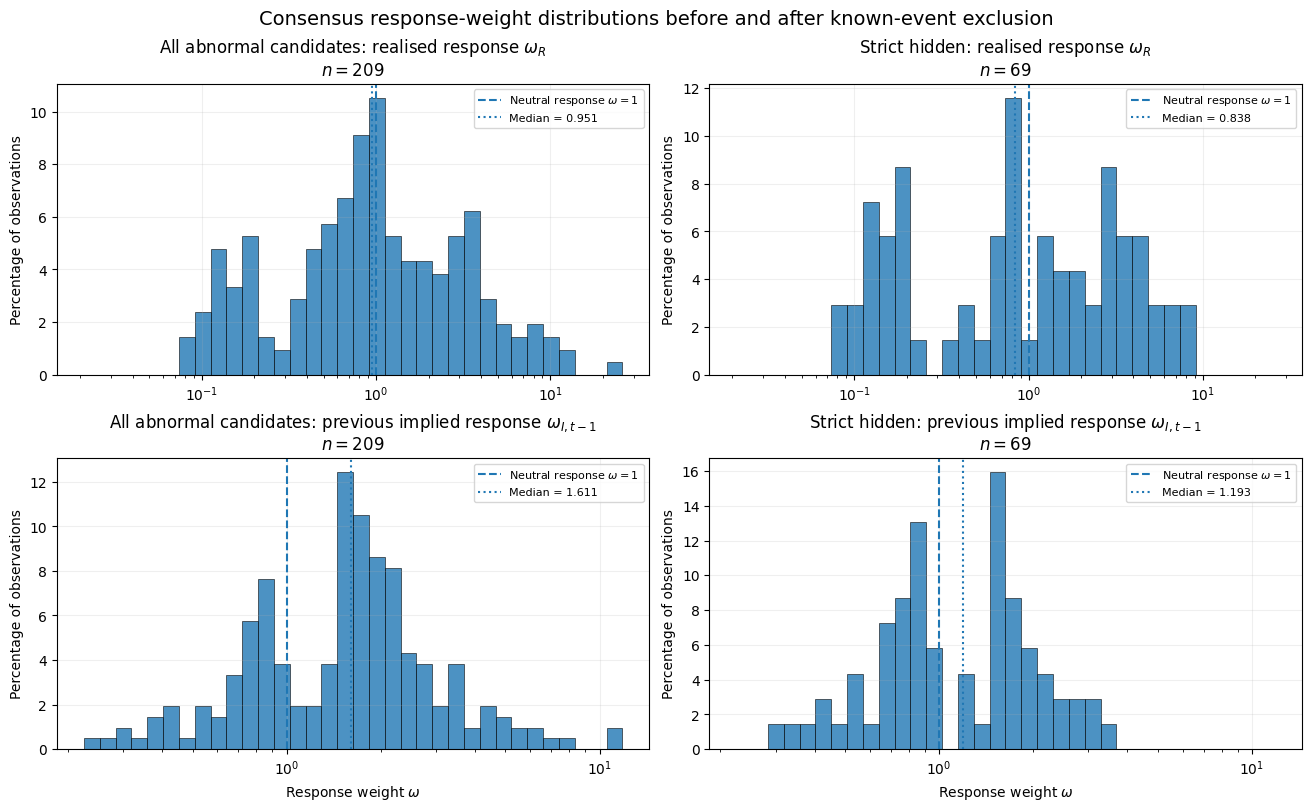

In [26]:
# ------------------------------------------------------------
# Response-weight distributions before and after
# known-event exclusion
#
# Left column:
#   All abnormal TEST candidates before excluding the six
#   known scheduled-event families (n = 209 at alpha = 0.05)
#
# Right column:
#   Strict-hidden candidates after excluding detector pairs
#   coincident with the six known event families (n = 69)
# ------------------------------------------------------------


# All abnormal TEST candidates before known-event exclusion
all_candidate_weights = primary_all_candidate_days.copy()

# Strict-hidden candidates after known-event exclusion
strict_hidden_weights = primary_candidate_days.copy()


def clean_positive(series):
    """
    Keep only finite, strictly positive response weights.

    Response weights must be positive for the logarithmic x-axis.
    The earlier positivity audit has already verified that valid
    response ratios satisfy this requirement.
    """
    values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)

    return values[
        np.isfinite(values)
        & (values > 0)
    ]


# ------------------------------------------------------------
# Extract realised and implied consensus response weights
# ------------------------------------------------------------

# Realised response:
# omega_R = actual R_t / ordinary admissible background forecast
all_R = clean_positive(
    all_candidate_weights["omega_R_consensus"]
)

hidden_R = clean_positive(
    strict_hidden_weights["omega_R_consensus"]
)


# Previous-model-day implied response:
# omega_I_prev = actual I_(t-1) / ordinary admissible background forecast
all_I = clean_positive(
    all_candidate_weights["omega_I_prev_consensus"]
)

hidden_I = clean_positive(
    strict_hidden_weights["omega_I_prev_consensus"]
)


# ------------------------------------------------------------
# Common histogram bins within each channel
#
# Using the same bins for the left and right panels makes the
# before/after-known-event comparison directly interpretable.
#
# Log-spaced bins are used because the weight distributions
# are strongly right-skewed.
# ------------------------------------------------------------

R_min = min(all_R.min(), hidden_R.min())
R_max = max(all_R.max(), hidden_R.max())

R_bins = np.logspace(
    np.log10(R_min),
    np.log10(R_max),
    35
)


I_min = min(all_I.min(), hidden_I.min())
I_max = max(all_I.max(), hidden_I.max())

I_bins = np.logspace(
    np.log10(I_min),
    np.log10(I_max),
    35
)


# ------------------------------------------------------------
# Plotting helper
# ------------------------------------------------------------

def plot_weight_hist(ax, values, bins, title):
    """
    Plot a response-weight histogram as a percentage of the
    observations in that sample.

    omega = 1:
        actual response equals ordinary model background

    omega > 1:
        actual response is above background

    omega < 1:
        actual response is below background
    """

    # Express histogram height as percentage rather than raw count.
    # This makes samples of different sizes directly comparable.
    histogram_weights = (
        np.ones(len(values), dtype=float)
        * 100.0
        / len(values)
    )

    ax.hist(
        values,
        bins=bins,
        weights=histogram_weights,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5,
    )

    # Neutral-response reference:
    # omega = 1 means actual = ordinary forecast background.
    ax.axvline(
        1.0,
        linestyle="--",
        linewidth=1.5,
        label=r"Neutral response $\omega=1$",
    )

    # Sample median
    median_value = np.median(values)

    ax.axvline(
        median_value,
        linestyle=":",
        linewidth=1.5,
        label=fr"Median = {median_value:.3f}",
    )

    # Logarithmic x-axis keeps the raw omega units while
    # making both small and very large response weights visible.
    ax.set_xscale("log")

    ax.set_title(
        f"{title}\n"
        rf"$n={len(values)}$"
    )

    ax.set_ylabel("Percentage of observations")

    ax.grid(
        alpha=0.2
    )

    ax.legend(
        fontsize=8
    )


# ------------------------------------------------------------
# Construct the 2 x 2 figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 8),
    sharex="row",
    constrained_layout=True,
)


# ------------------------------------------------------------
# Top row: realised response weights
# ------------------------------------------------------------

# Top-left:
# all 209 abnormal TEST candidates before known-event exclusion
plot_weight_hist(
    axes[0, 0],
    all_R,
    R_bins,
    r"All abnormal candidates: realised response $\omega_R$",
)


# Top-right:
# 69 strict-hidden candidates after known-event exclusion
plot_weight_hist(
    axes[0, 1],
    hidden_R,
    R_bins,
    r"Strict hidden: realised response $\omega_R$",
)


# ------------------------------------------------------------
# Bottom row: previous-model-day implied response weights
# ------------------------------------------------------------

# Bottom-left:
# all 209 abnormal TEST candidates before known-event exclusion
plot_weight_hist(
    axes[1, 0],
    all_I,
    I_bins,
    r"All abnormal candidates: previous implied response $\omega_{I,t-1}$",
)


# Bottom-right:
# 69 strict-hidden candidates after known-event exclusion
plot_weight_hist(
    axes[1, 1],
    hidden_I,
    I_bins,
    r"Strict hidden: previous implied response $\omega_{I,t-1}$",
)


# x-axis labels
axes[1, 0].set_xlabel(
    r"Response weight $\omega$"
)

axes[1, 1].set_xlabel(
    r"Response weight $\omega$"
)


# Overall figure title
fig.suptitle(
    "Consensus response-weight distributions before and after known-event exclusion",
    fontsize=14,
)


plt.show()

In [6]:
sensitivity_rows = []
for alpha in SENSITIVITY_ALPHAS:
    flagged = primary_test_scores.copy()
    flagged['R_abnormal_alpha'] = flagged['consensus_tail_p_R'].le(threshold_lookup.loc[('R',alpha)])
    flagged['I_abnormal_alpha'] = flagged['consensus_tail_p_I_prev'].le(threshold_lookup.loc[('I',alpha)])
    flagged['state_alpha'] = np.select([flagged['R_abnormal_alpha'] & ~flagged['I_abnormal_alpha'], ~flagged['R_abnormal_alpha'] & flagged['I_abnormal_alpha'], flagged['R_abnormal_alpha'] & flagged['I_abnormal_alpha']], ['REALISED_ONLY','IMPLIED_ONLY','JOINT'], default='NONE')
    flagged['strict_alpha'] = flagged['state_alpha'].ne('NONE') & ~flagged['known_primary_event_pair']
    episode_input = flagged.copy()
    episode_input['primary_state'] = flagged['state_alpha']
    episode_input['strict_hidden_candidate'] = flagged['strict_alpha']
    episode_input['R_abnormal'] = flagged['R_abnormal_alpha']
    episode_input['I_abnormal_prev'] = flagged['I_abnormal_alpha']
    _, alpha_episodes = build_episodes(episode_input, 'primary_state', 'strict_hidden_candidate', f'E21_A{int(alpha*100):02d}_')
    candidates = flagged.loc[flagged['state_alpha'].ne('NONE')]
    sensitivity_rows.append({'alpha':alpha, 'R_threshold':threshold_lookup.loc[('R',alpha)], 'I_threshold':threshold_lookup.loc[('I',alpha)], 'candidate_day_count':int(len(candidates)), 'strict_hidden_candidate_day_count':int(flagged['strict_alpha'].sum()), 'realised_only_count':int(candidates['state_alpha'].eq('REALISED_ONLY').sum()), 'implied_only_count':int(candidates['state_alpha'].eq('IMPLIED_ONLY').sum()), 'joint_count':int(candidates['state_alpha'].eq('JOINT').sum()), 'strict_hidden_episode_count':int(len(alpha_episodes))})
primary_threshold_sensitivity = pd.DataFrame(sensitivity_rows)

def mbb_rate_draws(values, seed):
    values = np.asarray(values, float)
    n = len(values); starts = np.arange(n - BLOCK_LENGTH + 1)
    rng = np.random.default_rng(seed); blocks = rng.choice(starts, size=(BOOTSTRAP_REPS, int(np.ceil(n / BLOCK_LENGTH))), replace=True)
    positions = (blocks[..., None] + np.arange(BLOCK_LENGTH)).reshape(BOOTSTRAP_REPS, -1)[:, :n]
    return values[positions].mean(axis=1)

calibration_rows = []
for alpha in SENSITIVITY_ALPHAS:
    for target, column in [('R','consensus_tail_p_R'),('I','consensus_tail_p_I_prev')]:
        threshold = threshold_lookup.loc[(target,alpha)]
        validation_flags = primary_pairs.loc[primary_pairs['sample_split'].eq('validation'), column].le(threshold).to_numpy(float)
        test_flags = primary_pairs.loc[primary_pairs['sample_split'].eq('test'), column].le(threshold).to_numpy(float)
        validation_draws = mbb_rate_draws(validation_flags, BOOTSTRAP_SEED)
        test_draws = mbb_rate_draws(test_flags, BOOTSTRAP_SEED + 1)
        delta_draws = test_draws - validation_draws
        calibration_rows.append({'target':target,'alpha':alpha,'validation_abnormal_fraction':float(validation_flags.mean()),'validation_ci_low':float(np.quantile(validation_draws,.025)),'validation_ci_high':float(np.quantile(validation_draws,.975)),'test_abnormal_fraction':float(test_flags.mean()),'test_ci_low':float(np.quantile(test_draws,.025)),'test_ci_high':float(np.quantile(test_draws,.975)),'test_minus_validation':float(test_flags.mean()-validation_flags.mean()),'difference_ci_low':float(np.quantile(delta_draws,.025)),'difference_ci_high':float(np.quantile(delta_draws,.975)),'threshold':threshold,'bootstrap_method':'chronological_moving_block_length_5'})
primary_calibration_transfer = pd.DataFrame(calibration_rows)

event_rows=[]
for family in PRIMARY_FAMILIES:
    event_pairs=primary_test_scores.loc[primary_test_scores['R_event_families'].str.contains(family,regex=False) | primary_test_scores['I_prev_event_families'].str.contains(family,regex=False)]
    event_rows.append({'family':family,'n_eligible_event_pairs':int(len(event_pairs)),'n_candidate_event_pairs':int(event_pairs['is_candidate'].sum()),'candidate_rate':float(event_pairs['is_candidate'].mean()) if len(event_pairs) else np.nan,'realised_only_count':int(event_pairs['primary_state'].eq('REALISED_ONLY').sum()),'implied_only_count':int(event_pairs['primary_state'].eq('IMPLIED_ONLY').sum()),'joint_count':int(event_pairs['primary_state'].eq('JOINT').sum())})
known_event_detection_diagnostic=pd.DataFrame(event_rows)
display(primary_threshold_sensitivity)
display(primary_calibration_transfer)
display(known_event_detection_diagnostic)


,alpha,R_threshold,I_threshold,candidate_day_count,strict_hidden_candidate_day_count,realised_only_count,implied_only_count,joint_count,strict_hidden_episode_count
0,0.10,0.104869,0.134501,349,154,137,168,44,143
1,0.05,0.051034,0.062683,209,69,65,125,19,65
2,0.01,0.011985,0.012255,69,21,30,37,2,18


,target,alpha,validation_abnormal_fraction,validation_ci_low,validation_ci_high,test_abnormal_fraction,test_ci_low,test_ci_high,test_minus_validation,difference_ci_low,difference_ci_high,threshold,bootstrap_method
0,R,0.10,0.109444,0.090909,0.128861,0.159894,0.134276,0.185534,0.050450,0.017773,0.081350,0.104869,chronological_moving_block_length_5
1,I,0.10,0.100618,0.081200,0.120918,0.187279,0.164311,0.210247,0.086661,0.056635,0.117564,0.134501,chronological_moving_block_length_5
2,R,0.05,0.051192,0.038835,0.065313,0.074205,0.056537,0.090106,0.023013,0.000060,0.044209,0.051034,chronological_moving_block_length_5
3,I,0.05,0.048544,0.035305,0.062665,0.127208,0.107774,0.147527,0.078665,0.054821,0.102506,0.062683,chronological_moving_block_length_5
4,R,0.01,0.011474,0.005296,0.018535,0.028269,0.017668,0.038869,0.016795,0.003548,0.029161,0.011985,chronological_moving_block_length_5
5,I,0.01,0.005296,0.001765,0.009709,0.034452,0.024735,0.045053,0.029157,0.018556,0.040639,0.012255,chronological_moving_block_length_5


,family,n_eligible_event_pairs,n_candidate_event_pairs,candidate_rate,realised_only_count,implied_only_count,joint_count
0,FOMC,70,20,0.285714,7,10,3
1,US Employment,103,37,0.359223,9,25,3
2,US CPI,106,33,0.311321,4,25,4
3,BoJ,72,43,0.597222,2,35,6
4,JPY National CPI,107,26,0.242991,12,12,2
5,JPY GDP,74,6,0.081081,0,6,0


## 21.16–21.19 Sparse chronology, maps, MoF validation, and circular shifts

The headline sparse timeline intentionally shows only strict-hidden episode peaks, their states, official MoF intervention dates, and the six-family post-detection event rug. It omits ordinary TEST observations so that clustering and proximity can be read directly; the rug provides scheduled-event context without hundreds of full-height lines.

The abnormality map answers how empirically unusual each realised/implied pair is: the frozen tail thresholds partition NONE, REALISED_ONLY, IMPLIED_ONLY, and JOINT. The signed log-weight map answers a different question—above or below the ordinary background, and by how much—so its zero lines correspond to $\omega=1$.

Official **Japanese Ministry of Finance** USD-sold/JPY-bought intervention dates are external post-detection information, not detector inputs. The analysis preserves campaign grouping and ±5 primary / ±7 / ±10 sensitivity windows. Matches are temporal association, not intervention causality. Circular shifts keep interventions fixed while moving the complete episode pattern through 1,209 TEST days, preserving spacing and clustering; the resulting probability asks whether the same temporal pattern would match as well elsewhere.


In [7]:
MOF_RAW = PROJECT_DIR / 'Data' / 'foreign_exchange_intervention_operations.csv'
with MOF_RAW.open('r', encoding='cp932') as handle:
    mof_lines = handle.readlines()
header_row = next(i for i,line in enumerate(mof_lines) if 'Year' in line and 'Currency pairs' in line)
mof_raw = pd.read_csv(MOF_RAW, encoding='cp932', skiprows=header_row)
year = pd.to_numeric(mof_raw['Year'], errors='coerce').ffill()
month = mof_raw['Month'].astype('string').replace({'':pd.NA}).ffill()
day = pd.to_numeric(mof_raw['Day'], errors='coerce')


In [8]:
amount = pd.to_numeric(mof_raw['金額(amount)'].astype('string').str.replace(',','',regex=False), errors='coerce')
direction_text = mof_raw['Currency pairs'].astype('string')
date = pd.to_datetime(year.round().astype('Int64').astype('string') + '-' + month + '-' + day.round().astype('Int64').astype('string'), format='%Y-%b-%d', errors='coerce')
usd_sold_jpy_bought = direction_text.str.contains(r'US dollar \(sold\).*Japanese yen \(bought\)', case=False, regex=True, na=False)
mof = pd.DataFrame({'intervention_date':date,'amount_100m_yen':amount,'currency_direction':direction_text}).loc[usd_sold_jpy_bought & date.notna() & amount.notna()].copy()
test_panel = panel.loc[panel['sample_split'].eq('test'), ['model_day','canonical_index']].copy()
assert len(test_panel) == 1209 and test_panel['canonical_index'].diff().dropna().eq(1).all()
mof = mof.loc[mof['intervention_date'].between(test_panel['model_day'].min(), test_panel['model_day'].max())]
mof_interventions = mof.groupby('intervention_date',as_index=False).agg(amount_100m_yen=('amount_100m_yen','sum'),currency_direction=('currency_direction',lambda x:' | '.join(sorted(set(x.astype(str)))))).sort_values('intervention_date').reset_index(drop=True)


In [9]:
test_dates = test_panel['model_day'].to_numpy(dtype='datetime64[ns]')
test_indices = test_panel['canonical_index'].to_numpy(int)
mapped=[]
for row in mof_interventions.itertuples(index=False):
    pos=int(np.searchsorted(test_dates,np.datetime64(row.intervention_date),side='left'))
    assert pos < len(test_dates)
    mapped.append({**row._asdict(),'mapped_model_day':pd.Timestamp(test_dates[pos]),'mapped_canonical_index':int(test_indices[pos])})
mof_interventions=pd.DataFrame(mapped)
mof_interventions['new_campaign']=mof_interventions['intervention_date'].diff().dt.days.fillna(999).gt(5)
mof_interventions['campaign_id']='MOF_CAMPAIGN_'+mof_interventions['new_campaign'].cumsum().astype(int).astype(str).str.zfill(2)
mof_campaigns=mof_interventions.groupby('campaign_id',as_index=False).size()
episode_peaks=primary_hidden_episodes.merge(panel[['model_day','canonical_index']],left_on='peak_day',right_on='model_day',how='left',validate='one_to_one').drop(columns='model_day')
match_rows=[]
for intervention in mof_interventions.itertuples(index=False):
    distances=episode_peaks['canonical_index']-intervention.mapped_canonical_index
    nearest=int(distances.abs().min())
    chosen=episode_peaks.loc[distances.abs().eq(nearest)].sort_values(['peak_day','hidden_episode_id']).iloc[0]
    signed=int(chosen['canonical_index']-intervention.mapped_canonical_index)
    match_rows.append({**intervention._asdict(),'nearest_episode_id':chosen['hidden_episode_id'],'nearest_episode_state':chosen['primary_state'],'nearest_episode_peak_day':chosen['peak_day'],'signed_model_day_distance':signed,'absolute_model_day_distance':nearest,'timing_relation':'PRE_INTERVENTION' if signed<0 else 'POST_INTERVENTION' if signed>0 else 'CONTEMPORANEOUS'})
mof_intervention_matches=pd.DataFrame(match_rows)
for window in [5,7,10]: mof_intervention_matches[f'hit_within_{window}']=mof_intervention_matches['absolute_model_day_distance'].le(window)
episode_positions=episode_peaks['canonical_index'].to_numpy(int)-int(test_panel['canonical_index'].min())
intervention_positions=mof_interventions['mapped_canonical_index'].to_numpy(int)-int(test_panel['canonical_index'].min())
campaign_ids=mof_interventions['campaign_id'].to_numpy(object)
null_rows=[]
for shift in range(len(test_panel)):
    shifted=(episode_positions+shift)%len(test_panel); distances=np.abs(intervention_positions[:,None]-shifted[None,:])
    for window in [5,7,10]:
        hits=(distances<=window).any(axis=1)
        null_rows.append({'shift':shift,'window':window,'date_hit_count':int(hits.sum()),'campaign_hit_count':int(sum(hits[campaign_ids==cid].any() for cid in mof_campaigns['campaign_id']))})
mof_circular_shift_null=pd.DataFrame(null_rows)
summary=[]
for window in [5,7,10]:
    hits=mof_intervention_matches[f'hit_within_{window}']; null=mof_circular_shift_null.loc[mof_circular_shift_null['window'].eq(window)]; campaigns=int(mof_intervention_matches.loc[hits,'campaign_id'].nunique())
    summary.append({'window_model_days':window,'role':'PRIMARY' if window==5 else 'SENSITIVITY','date_hit_count':int(hits.sum()),'campaign_hit_count':campaigns,'date_hit_null_mean':float(null['date_hit_count'].mean()),'date_hit_randomisation_p':float((null['date_hit_count']>=hits.sum()).mean()),'campaign_hit_null_mean':float(null['campaign_hit_count'].mean()),'campaign_hit_randomisation_p':float((null['campaign_hit_count']>=campaigns).mean())})
mof_validation_primary=pd.DataFrame(summary)
display(mof_validation_primary)


,window_model_days,role,date_hit_count,campaign_hit_count,date_hit_null_mean,date_hit_randomisation_p,campaign_hit_null_mean,campaign_hit_randomisation_p
0,5,PRIMARY,9,4,4.019851,0.037221,2.207610,0.125724
1,7,SENSITIVITY,9,4,4.987593,0.072787,2.665012,0.215054
2,10,SENSITIVITY,9,4,6.186931,0.143093,3.229942,0.403639


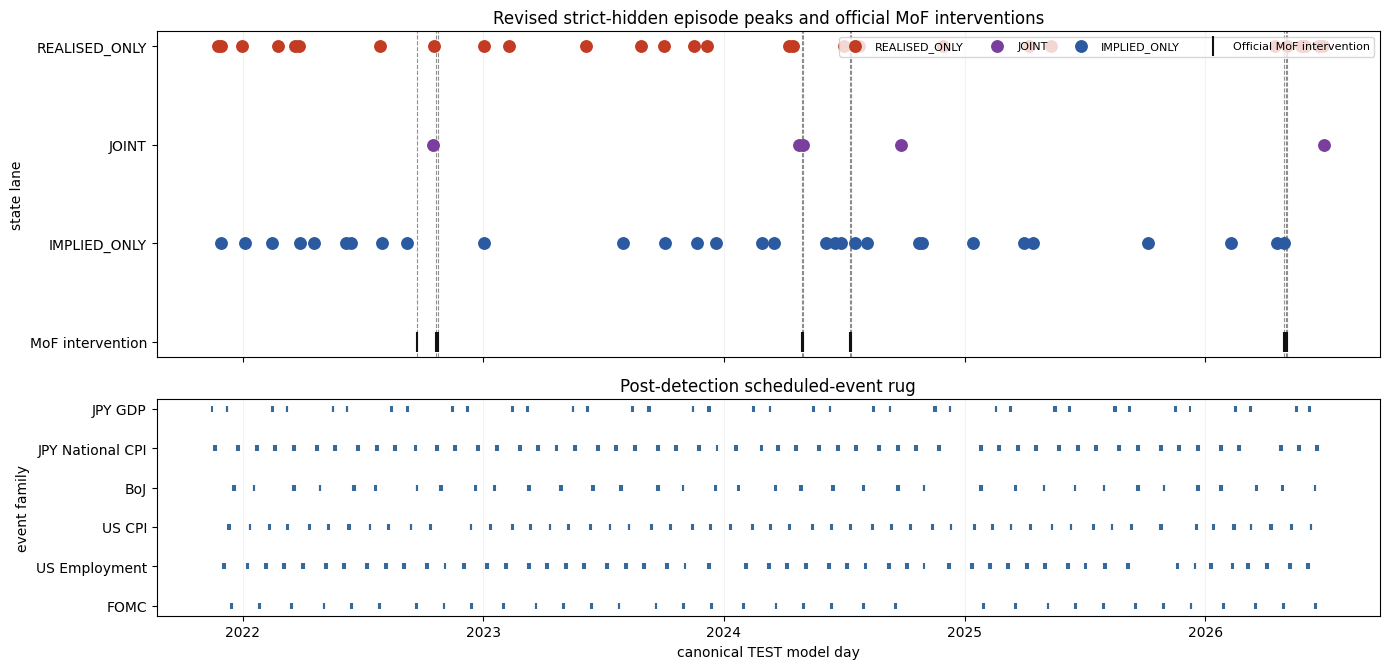

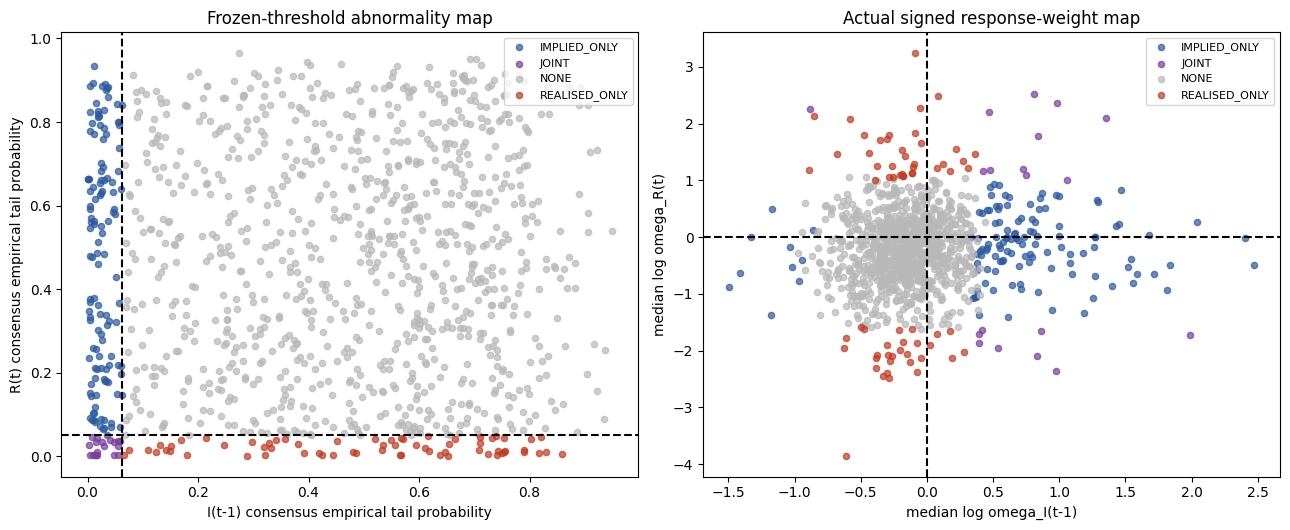

In [10]:
# Headline chronology: sparse revised strict-hidden episode peaks, MoF dates, and a post-detection event rug.
state_colors = {'REALISED_ONLY':'#c23b22','JOINT':'#7a3e9d','IMPLIED_ONLY':'#2c5aa0'}
state_lanes = {'REALISED_ONLY':3,'JOINT':2,'IMPLIED_ONLY':1}
fig, (ax, rug) = plt.subplots(2,1,figsize=(14,6.8),sharex=True,gridspec_kw={'height_ratios':[3,2]})
for state, lane in state_lanes.items():
    part = primary_hidden_episodes.loc[primary_hidden_episodes['primary_state'].eq(state)]
    ax.scatter(part['peak_day'], np.repeat(lane, len(part)), s=68, color=state_colors[state], label=state, zorder=3)
for day in mof_interventions['mapped_model_day']:
    ax.axvline(day, color='#222222', ls='--', lw=.8, alpha=.5)
ax.scatter(mof_interventions['mapped_model_day'], np.zeros(len(mof_interventions)), marker='|', s=190, color='#111111', label='Official MoF intervention', zorder=4)
ax.set_yticks([0,1,2,3], ['MoF intervention','IMPLIED_ONLY','JOINT','REALISED_ONLY'])
ax.set(title='Revised strict-hidden episode peaks and official MoF interventions', ylabel='state lane')
ax.grid(axis='x', alpha=.16); ax.legend(ncol=4, fontsize=8, loc='upper right')
for row, family in enumerate(PRIMARY_FAMILIES):
    r_days = primary_test_scores.loc[primary_test_scores['R_event_families'].str.contains(family,regex=False), 'model_day']
    i_days = primary_test_scores.loc[primary_test_scores['I_prev_event_families'].str.contains(family,regex=False), 'model_day']
    days = pd.Index(r_days).union(pd.Index(i_days))
    rug.scatter(days, np.repeat(row, len(days)), s=18, marker='|', color='#356a9a')
rug.set_yticks(range(len(PRIMARY_FAMILIES)), PRIMARY_FAMILIES)
rug.set(title='Post-detection scheduled-event rug', xlabel='canonical TEST model day', ylabel='event family')
rug.grid(axis='x', alpha=.14); fig.tight_layout()
fig.savefig(FIGURES/'21_figure_hidden_episode_mof_timeline.png',dpi=180)
plt.show()

# Supplementary geometry: tail-score thresholds classify the four states; log weights retain direction.
state_colors_full = {'NONE':'#b8b8b8', **state_colors}
fig, axes = plt.subplots(1,2,figsize=(13,5.4))
for state, part in primary_test_scores.groupby('primary_state'):
    axes[0].scatter(part['consensus_tail_p_I_prev'],part['consensus_tail_p_R'],s=20,color=state_colors_full[state],label=state,alpha=.7)
    axes[1].scatter(part['log_omega_I_prev_consensus'],part['log_omega_R_consensus'],s=20,color=state_colors_full[state],label=state,alpha=.7)
axes[0].axvline(threshold_lookup.loc[('I',.05)],color='black',ls='--'); axes[0].axhline(threshold_lookup.loc[('R',.05)],color='black',ls='--')
axes[0].set(xlabel='I(t-1) consensus empirical tail probability',ylabel='R(t) consensus empirical tail probability',title='Frozen-threshold abnormality map')
axes[1].axvline(0,color='black',ls='--'); axes[1].axhline(0,color='black',ls='--')
axes[1].set(xlabel='median log omega_I(t-1)',ylabel='median log omega_R(t)',title='Actual signed response-weight map')
for axis in axes: axis.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIGURES/'21_revised_state_maps.png',dpi=180); plt.show()


Left Panel:
- upper-right --> neither abnormal
- lower-right --> realised only
- upper-left --> implied only
- lower-left --> joint

Right Panel:
- upper-right --> both above background
- upper-left --> realised above, implied below
- lower-right --> realised below, implied above
- lower-left --> both below background

## 21.19a Economic context of revised strict-hidden episodes

Statistical abnormality alone does not establish a meaningful economic event. This post-detection table is a descriptive inspection tool: it combines each strict-hidden episode peak’s state, actual response weights, volatility quantities, spot-movement context, calendar context, and nearest official MoF intervention. It changes no detector, threshold, state, episode, or causal interpretation.

The table deliberately retains $\omega_R$ and $\omega_I$: for example, $\omega_R=3$ means realised variance was approximately three times its ordinary model background, while $\omega_I=0.4$ means prior-model-day implied variance was about 40% of its background. Magnitude and empirical tail probability answer different questions.

The frozen N15 daily model panel provides the already-defined signed USD/JPY canonical model-day log return, 'within_session_log_return': the sum of within-session hourly log returns over $[D-1\ 17{:}00\ \mathrm{New\ York}, D\ 17{:}00\ \mathrm{New\ York})$. It is carried here unchanged as 'usdjpy_model_day_return'; N16's 'squared_return' is verified to equal this return squared and is displayed as $Q_t$.

$R_t = 252\sum_{\tau\in t} r_\tau^2$ measures accumulated intraday realised variation, whereas $Q_t=(\sum_{\tau\in t}r_\tau)^2$ measures squared net model-day USD/JPY displacement. Large $R_t$ and large $Q_t$ indicate substantial variation accompanied by a large net move; large $R_t$ with relatively small $Q_t$ indicates substantial intraday movement with less net displacement. The signed return also shows direction. These are post-detection context only.


In [11]:
# One descriptive row per existing strict-hidden episode peak; detector objects are read only.
peak_fields = ['model_day','canonical_index','omega_R_consensus','omega_I_prev_consensus','log_omega_R_consensus','log_omega_I_prev_consensus','consensus_tail_p_R','consensus_tail_p_I_prev','R_abnormal','I_abnormal_prev','R_direction','I_direction','R_event_families','I_prev_event_families','known_primary_event_pair','is_month_end_t','is_month_end_prev','month_end_pair']
peak_rows = primary_hidden_episodes.merge(primary_candidate_days[peak_fields], left_on='peak_day', right_on='model_day', how='left', validate='one_to_one').drop(columns='model_day')
peak_rows = peak_rows.merge(panel[['model_day','R','I','squared_return','usdjpy_model_day_return','abs_usdjpy_model_day_return','previous_model_day']], left_on='peak_day', right_on='model_day', how='left', validate='one_to_one').drop(columns='model_day').rename(columns={'R':'R_t','I':'I_t','squared_return':'Q_t'})
previous_i = panel[['model_day','I']].rename(columns={'model_day':'previous_model_day','I':'I_prev'})
peak_rows = peak_rows.merge(previous_i,on='previous_model_day',how='left',validate='many_to_one')
scheduled = event_mapping.loc[event_mapping['event_label'].isin(PRIMARY_FAMILIES), ['event_label','target_model_day']].merge(panel[['model_day','canonical_index']],left_on='target_model_day',right_on='model_day',how='inner')
scheduled = scheduled.groupby(['canonical_index','model_day'],as_index=False)['event_label'].agg(lambda x:' | '.join(sorted(set(x))))
event_context=[]; mof_context=[]
for row in peak_rows.itertuples(index=False):
    dist = scheduled['canonical_index'] - row.canonical_index
    near = scheduled.loc[dist.abs().eq(dist.abs().min())].sort_values(['model_day','event_label']).iloc[0]
    event_context.append({'hidden_episode_id':row.hidden_episode_id,'nearest_scheduled_event_family':near.event_label,'nearest_scheduled_event_model_day':near.model_day,'scheduled_event_distance_model_days':int(row.canonical_index-near.canonical_index)})
    mof_dist = mof_interventions['mapped_canonical_index'] - row.canonical_index
    mof_near = mof_interventions.loc[mof_dist.abs().eq(mof_dist.abs().min())].sort_values('intervention_date').iloc[0]
    signed = int(row.canonical_index-mof_near.mapped_canonical_index)
    mof_context.append({'hidden_episode_id':row.hidden_episode_id,'nearest_MoF_intervention_date':mof_near.intervention_date,'MoF_distance_model_days':signed,'within_MoF_5_model_days':abs(signed)<=5,'within_MoF_7_model_days':abs(signed)<=7,'within_MoF_10_model_days':abs(signed)<=10})
hidden_episode_economic_context = peak_rows.merge(pd.DataFrame(event_context),on='hidden_episode_id',validate='one_to_one').merge(pd.DataFrame(mof_context),on='hidden_episode_id',validate='one_to_one').sort_values('peak_tail_p').reset_index(drop=True)
hidden_episode_economic_context_summary = hidden_episode_economic_context.groupby('primary_state',as_index=False).agg(n_episodes=('hidden_episode_id','size'),median_omega_R=('omega_R_consensus','median'),median_omega_I_prev=('omega_I_prev_consensus','median'),fraction_month_end=('month_end_pair','mean'),fraction_within_MoF_5=('within_MoF_5_model_days','mean'),fraction_within_5_model_days_of_scheduled_event=('scheduled_event_distance_model_days',lambda x:float((x.abs()<=5).mean())))
context_display_columns = ['peak_day','primary_state','omega_R_consensus','omega_I_prev_consensus','usdjpy_model_day_return','abs_usdjpy_model_day_return','Q_t','R_direction','I_direction','R_t','I_prev','I_t','nearest_scheduled_event_family','scheduled_event_distance_model_days','month_end_pair','nearest_MoF_intervention_date','MoF_distance_model_days']
display(hidden_episode_economic_context[context_display_columns].head(15))
display(hidden_episode_economic_context_summary)


,peak_day,primary_state,omega_R_consensus,omega_I_prev_consensus,usdjpy_model_day_return,abs_usdjpy_model_day_return,Q_t,R_direction,I_direction,R_t,I_prev,I_t,nearest_scheduled_event_family,scheduled_event_distance_model_days,month_end_pair,nearest_MoF_intervention_date,MoF_distance_model_days
0,2021-11-25,REALISED_ONLY,0.090839,0.741822,-0.000555,0.000555,3.075811e-07,BELOW_BACKGROUND,BELOW_BACKGROUND,0.000350,0.004614,0.003148,JPY National CPI,4,False,2022-09-22,-215
1,2023-12-07,REALISED_ONLY,6.085333,0.621754,-0.021869,0.021869,4.782439e-04,ABOVE_BACKGROUND,BELOW_BACKGROUND,0.028247,0.006127,0.027963,JPY GDP | US Employment,-1,False,2024-04-29,-102
2,2026-05-06,REALISED_ONLY,8.513064,0.427088,-0.009546,0.009546,9.112794e-05,ABOVE_BACKGROUND,BELOW_BACKGROUND,0.043301,0.006959,0.011103,US Employment,-2,False,2026-05-06,0
3,2024-09-27,JOINT,5.932843,2.323036,-0.018219,0.018219,3.319378e-04,ABOVE_BACKGROUND,ABOVE_BACKGROUND,0.130765,0.041220,0.019926,BoJ | JPY National CPI,5,False,2024-07-12,55
4,2026-06-29,REALISED_ONLY,0.086551,0.720914,0.001239,0.001239,1.534852e-06,BELOW_BACKGROUND,BELOW_BACKGROUND,0.000220,0.002785,0.002812,JPY National CPI,6,False,2026-05-06,38
5,2024-10-28,IMPLIED_ONLY,0.751092,3.257080,0.000316,0.000316,1.001393e-07,BELOW_BACKGROUND,ABOVE_BACKGROUND,0.011015,0.032361,0.013803,BoJ,-3,False,2024-07-12,76
6,2022-03-28,REALISED_ONLY,6.029288,0.752192,0.015032,0.015032,2.259723e-04,ABOVE_BACKGROUND,BELOW_BACKGROUND,0.037251,0.007203,0.021712,US Employment,-4,False,2022-09-22,-128
7,2021-11-29,IMPLIED_ONLY,1.004328,3.551621,-0.001487,0.001487,2.212597e-06,ABOVE_BACKGROUND,ABOVE_BACKGROUND,0.012163,0.014204,0.007523,US Employment,-4,False,2022-09-22,-213
8,2026-06-02,REALISED_ONLY,0.100234,0.678126,0.001530,0.001530,2.341521e-06,BELOW_BACKGROUND,BELOW_BACKGROUND,0.000208,0.001851,0.003942,US Employment,-3,False,2026-05-06,19
9,2025-05-12,REALISED_ONLY,5.216584,0.957260,0.015022,0.015022,2.256500e-04,ABOVE_BACKGROUND,BELOW_BACKGROUND,0.049819,0.015702,0.015445,US CPI,-1,False,2024-07-12,216


,primary_state,n_episodes,median_omega_R,median_omega_I_prev,fraction_month_end,fraction_within_MoF_5,fraction_within_5_model_days_of_scheduled_event
0,IMPLIED_ONLY,30,0.832382,1.734624,0.166667,0.066667,0.966667
1,JOINT,5,0.193271,2.295723,0.400000,0.600000,0.800000
2,REALISED_ONLY,30,2.936851,0.814688,0.200000,0.100000,0.966667


### How to inspect an episode peak

Start with the state and the actual $\omega_R$ / $\omega_I$ values: are realised and implied responses above or below their ordinary backgrounds? Then inspect nearby scheduled-event distance, month-end status, and signed MoF distance. Here a negative MoF distance means the hidden peak occurred before the intervention, zero is contemporaneous in canonical model-day time, and positive means after it. A nearby calendar entry is context only; an unexplained episode is not proof of an unobservable or economically novel event, but a candidate for later manual investigation.


## 21.19b Scheduled-event proximity baseline

A strict-hidden episode has no six-family scheduled event on the canonical $R_t/I_{t-1}$ detector pair that assigned its state. It need not be far from a scheduled event. This descriptive audit uses the same observed-model-day positions and exactly the six frozen event families; it does not alter hidden status or add an inferential test.

The all-eligible TEST rate answers how much of the entire detector chronology lies near a scheduled event. The conditional strict-hidden-eligible TEST rate answers how often ordinary TEST dates that could themselves have been classified as strict hidden (their existing known_primary_event_pair flag is false) lie near an event. Strict-hidden episode peaks are compared primarily with that conditional population; the all-TEST comparison remains a calendar-density diagnostic.


In [12]:
# Descriptive only: distances use the existing canonical observed model-day index.
from IPython.display import Markdown
strict_hidden_status_before_proximity = primary_candidate_days[['model_day','strict_hidden_candidate','primary_state']].copy()
eligible_test_pairs = primary_test_scores[['model_day','canonical_index','known_primary_event_pair']].copy().reset_index(drop=True)
assert eligible_test_pairs['model_day'].is_unique and eligible_test_pairs['canonical_index'].is_unique
assert eligible_test_pairs['known_primary_event_pair'].notna().all()
strict_hidden_eligible_test_pairs = eligible_test_pairs.loc[eligible_test_pairs['known_primary_event_pair'].eq(False)].copy().reset_index(drop=True)
assert len(strict_hidden_eligible_test_pairs) <= len(eligible_test_pairs)
assert strict_hidden_eligible_test_pairs['known_primary_event_pair'].eq(False).all()
event_positions = scheduled['canonical_index'].drop_duplicates().sort_values().to_numpy(dtype=int)
assert len(event_positions) > 0

def minimum_scheduled_event_distance(canonical_positions):
    canonical_positions = np.asarray(canonical_positions, dtype=int)
    return np.abs(canonical_positions[:, None] - event_positions[None, :]).min(axis=1)

eligible_test_pairs['nearest_scheduled_event_distance_model_days'] = minimum_scheduled_event_distance(eligible_test_pairs['canonical_index'])
strict_hidden_eligible_test_pairs['nearest_scheduled_event_distance_model_days'] = minimum_scheduled_event_distance(strict_hidden_eligible_test_pairs['canonical_index'])
strict_hidden_episode_peaks = hidden_episode_economic_context[['hidden_episode_id','peak_day','primary_state','canonical_index']].copy()
strict_hidden_episode_peaks['nearest_scheduled_event_distance_model_days'] = minimum_scheduled_event_distance(strict_hidden_episode_peaks['canonical_index'])
baseline_rows = []
for window in [1, 2, 3, 5]:
    all_test_near = eligible_test_pairs['nearest_scheduled_event_distance_model_days'].le(window)
    conditional_near = strict_hidden_eligible_test_pairs['nearest_scheduled_event_distance_model_days'].le(window)
    peak_near = strict_hidden_episode_peaks['nearest_scheduled_event_distance_model_days'].le(window)
    all_test_rate = float(all_test_near.mean())
    conditional_rate = float(conditional_near.mean())
    peak_rate = float(peak_near.mean())
    baseline_rows.append({'window_model_days': window, 'n_eligible_test_pairs': len(eligible_test_pairs), 'n_all_test_near_event': int(all_test_near.sum()), 'all_test_rate': all_test_rate, 'n_strict_hidden_eligible_test_pairs': len(strict_hidden_eligible_test_pairs), 'n_strict_hidden_eligible_near_event': int(conditional_near.sum()), 'strict_hidden_eligible_rate': conditional_rate, 'n_strict_hidden_episodes': len(strict_hidden_episode_peaks), 'n_hidden_peaks_near_event': int(peak_near.sum()), 'hidden_peak_rate': peak_rate, 'hidden_minus_conditional_rate': peak_rate - conditional_rate, 'hidden_to_conditional_enrichment': (peak_rate / conditional_rate) if conditional_rate > 0 else np.nan, 'hidden_minus_all_test_rate': peak_rate - all_test_rate, 'hidden_to_all_test_enrichment': (peak_rate / all_test_rate) if all_test_rate > 0 else np.nan})
scheduled_event_proximity_baseline = pd.DataFrame(baseline_rows)
state_rows = []
for state in ['REALISED_ONLY','IMPLIED_ONLY','JOINT']:
    state_peaks = strict_hidden_episode_peaks.loc[strict_hidden_episode_peaks['primary_state'].eq(state)]
    state_rows.append({'primary_state': state, 'n_episodes': len(state_peaks), 'n_within_5': int(state_peaks['nearest_scheduled_event_distance_model_days'].le(5).sum()), 'within_5_rate': float(state_peaks['nearest_scheduled_event_distance_model_days'].le(5).mean()) if len(state_peaks) else np.nan})
scheduled_event_proximity_by_state = pd.DataFrame(state_rows)
scheduled_event_proximity_audit = pd.DataFrame([{'uses_canonical_index': True, 'event_positions_are_panel_positions': set(event_positions).issubset(set(panel['canonical_index'])), 'conditional_excludes_known_primary_event_pairs': strict_hidden_eligible_test_pairs['known_primary_event_pair'].eq(False).all(), 'conditional_uses_primary_test_eligible_pairs': set(strict_hidden_eligible_test_pairs['model_day']).issubset(set(primary_test_scores['model_day'])), 'n_eligible_test_pairs': len(eligible_test_pairs), 'n_strict_hidden_eligible_test_pairs': len(strict_hidden_eligible_test_pairs), 'n_strict_hidden_episode_peaks': len(strict_hidden_episode_peaks)}])
display(scheduled_event_proximity_baseline)
display(scheduled_event_proximity_by_state)
window_five = scheduled_event_proximity_baseline.loc[scheduled_event_proximity_baseline['window_model_days'].eq(5)].iloc[0]
if window_five['hidden_to_conditional_enrichment'] > 1.05:
    proximity_interpretation = 'After conditioning on dates eligible for strict-hidden classification, episode peaks remain more concentrated near scheduled macro events. This is consistent with anticipation, persistence, or delayed adjustment, but does not establish causality.'
elif window_five['hidden_to_conditional_enrichment'] < 0.95:
    proximity_interpretation = 'Strict-hidden episode peaks are not unusually concentrated near the scheduled-event calendar relative to otherwise eligible TEST dates.'
else:
    proximity_interpretation = 'Once the baseline is conditioned on dates eligible for strict-hidden classification, the apparent proximity of hidden episodes is largely explained by the density of the event calendar.'
display(Markdown(f"At the primary +/-5 model-day window, {window_five['hidden_peak_rate']:.1%} of strict-hidden episode peaks are near a scheduled event versus {window_five['strict_hidden_eligible_rate']:.1%} of strict-hidden-eligible TEST pairs (difference {window_five['hidden_minus_conditional_rate']:.1%}; enrichment {window_five['hidden_to_conditional_enrichment']:.2f}x). The all-eligible TEST rate is {window_five['all_test_rate']:.1%}. {proximity_interpretation}"))


,window_model_days,n_eligible_test_pairs,n_all_test_near_event,all_test_rate,n_strict_hidden_eligible_test_pairs,n_strict_hidden_eligible_near_event,strict_hidden_eligible_rate,n_strict_hidden_episodes,n_hidden_peaks_near_event,hidden_peak_rate,hidden_minus_conditional_rate,hidden_to_conditional_enrichment,hidden_minus_all_test_rate,hidden_to_all_test_enrichment
0,1,1132,639,0.564488,663,170,0.256410,65,15,0.230769,-0.025641,0.900000,-0.333718,0.408812
1,2,1132,860,0.759717,663,391,0.589744,65,36,0.553846,-0.035897,0.939130,-0.205871,0.729016
2,3,1132,996,0.879859,663,527,0.794872,65,48,0.738462,-0.056410,0.929032,-0.141397,0.839296
3,5,1132,1115,0.984982,663,646,0.974359,65,62,0.953846,-0.020513,0.978947,-0.031136,0.968389


,primary_state,n_episodes,n_within_5,within_5_rate
0,REALISED_ONLY,30,29,0.966667
1,IMPLIED_ONLY,30,29,0.966667
2,JOINT,5,4,0.800000


At the primary +/-5 model-day window, 95.4% of strict-hidden episode peaks are near a scheduled event versus 97.4% of strict-hidden-eligible TEST pairs (difference -2.1%; enrichment 0.98x). The all-eligible TEST rate is 98.5%. Once the baseline is conditioned on dates eligible for strict-hidden classification, the apparent proximity of hidden episodes is largely explained by the density of the event calendar.

## 21.20 Exercise 7: exploratory forward information

Exercise 7 asks whether strict hidden REALISED_ONLY, IMPLIED_ONLY, and JOINT states are descriptively associated with subsequent realised or implied dynamics relative to the control group. The output reports sample sizes, forward outcomes, and uncertainty. These are exploratory predictive-information comparisons, not trading profits; any small JOINT sample must be interpreted cautiously.


In [13]:
ex7 = primary_test_scores[['model_day','canonical_index','primary_state','strict_hidden_candidate','consensus_tail_p_R','consensus_tail_p_I_prev']].merge(panel[['model_day','R','I']],on='model_day',how='left',validate='one_to_one').sort_values('canonical_index').reset_index(drop=True)
for h in [1,5]:
    ex7[f'R_plus_{h}'] = ex7['R'].shift(-h)
    ex7[f'I_plus_{h}'] = ex7['I'].shift(-h)
    ex7[f'log_R_change_{h}'] = np.log(ex7[f'R_plus_{h}']) - np.log(ex7['R'])
    ex7[f'log_I_change_{h}'] = np.log(ex7[f'I_plus_{h}']) - np.log(ex7['I'])
ex7['exercise7_state'] = np.where(ex7['strict_hidden_candidate'],ex7['primary_state'],'NON_HIDDEN_CONTROL')
exercise7_forward_information = ex7.groupby('exercise7_state',as_index=False).agg(n_model_days=('model_day','size'),mean_log_R_change_1=('log_R_change_1','mean'),median_log_R_change_1=('log_R_change_1','median'),mean_log_I_change_1=('log_I_change_1','mean'),median_log_I_change_1=('log_I_change_1','median'),mean_log_R_change_5=('log_R_change_5','mean'),mean_log_I_change_5=('log_I_change_5','mean'))
exercise7_forward_information['standard_error_R_1'] = ex7.groupby('exercise7_state')['log_R_change_1'].sem().to_numpy()
exercise7_forward_information['standard_error_I_1'] = ex7.groupby('exercise7_state')['log_I_change_1'].sem().to_numpy()
display(exercise7_forward_information)


,exercise7_state,n_model_days,mean_log_R_change_1,median_log_R_change_1,mean_log_I_change_1,median_log_I_change_1,mean_log_R_change_5,mean_log_I_change_5,standard_error_R_1,standard_error_I_1
0,IMPLIED_ONLY,30,-0.122941,-0.237650,0.014242,-0.037886,-0.443685,-0.004587,0.129160,0.081849
1,JOINT,5,0.850405,1.368977,0.049813,-0.115201,1.498647,-0.279522,1.074158,0.329331
2,NON_HIDDEN_CONTROL,1063,-0.002397,-0.045182,0.001206,-0.024061,0.009729,0.002502,0.028345,0.015365
3,REALISED_ONLY,34,0.059695,-0.338073,-0.023518,-0.114905,-0.381520,-0.021226,0.276510,0.092855


## 21.21 Ex-ante $S_t$ signal analysis

$$S_t=\operatorname{median}_m\log\left(\frac{I_{t-1}}{\widehat F^{R,\mathrm{adm}}_{m,t}}\right).$$

$S_t>0$ means implied variance is rich relative to the ordinary realised-background benchmark, and $S_t<0$ means it is cheap. Crucially, $S_t$ is available before $R_t$. This differs from `hidden_state_primary`, which is ex post for model day $t$ because it needs the realised outcome. Since $S_t$ and realised response share the same denominator, evidence is benchmark-relative rather than an independent causal experiment.


In [14]:
r_forecasts = ratios.loc[ratios['target'].eq('R') & ratios['model'].isin(FLEXIBLE_MODELS), ['model_day','sample_split','model','ordinary_background_forecast']].merge(panel[['model_day','R','previous_model_day']],on='model_day',how='left',validate='many_to_one')
prior_I = panel[['model_day','I']].rename(columns={'model_day':'previous_model_day','I':'I_prev'})
r_forecasts = r_forecasts.merge(prior_I,on='previous_model_day',how='left',validate='many_to_one')
r_forecasts['signal_component'] = np.where(r_forecasts['I_prev'].gt(0) & r_forecasts['ordinary_background_forecast'].gt(0),np.log(r_forecasts['I_prev']/r_forecasts['ordinary_background_forecast']),np.nan)
signal = r_forecasts.groupby(['model_day','sample_split','previous_model_day'],as_index=False).agg(S=('signal_component','median'),n_models=('signal_component','count'))
validation_signal = signal.loc[signal['sample_split'].eq('validation'),'S']
S_cheap,S_rich = validation_signal.quantile([.2,.8])
signal['signal_group'] = np.select([signal['S'].le(S_cheap),signal['S'].ge(S_rich)],['IMPLIED_CHEAP','IMPLIED_RICH'],default='NEUTRAL')
signal['validation_defined_quintile'] = np.select([signal['S'].le(S_cheap),signal['S'].ge(S_rich)],['LOWEST_QUINTILE','HIGHEST_QUINTILE'],default='MIDDLE_QUINTILES')
signal_timing_audit = pd.DataFrame([{'signal_definition':'median log(I_{t-1}/F_R_adm_t)','timing':'EX_ANTE_BEFORE_R_T','threshold_source':'VALIDATION','S_cheap':S_cheap,'S_rich':S_rich}])
display(signal_timing_audit)


,signal_definition,timing,threshold_source,S_cheap,S_rich
0,median log(I_{t-1}/F_R_adm_t),EX_ANTE_BEFORE_R_T,VALIDATION,-0.061313,0.218425


## 21.22 Application-state panel and timing

The application panel explicitly distinguishes ex-ante signal information from ex-post hidden-state information. A model-day hidden state must not be treated as tradable before the same outcome that determines it. The timing fields are therefore part of the handoff contract for N22 onward.


In [15]:
application_state_panel = panel[['model_day','previous_model_day','sample_split','canonical_index','next_model_day']].merge(primary_pairs[['model_day','primary_state','is_candidate','strict_hidden_candidate','R_abnormal','I_abnormal_prev','R_direction','I_direction','omega_R_consensus','omega_I_prev_consensus','log_omega_R_consensus','log_omega_I_prev_consensus','consensus_tail_p_R','consensus_tail_p_I_prev','known_primary_event_pair','R_event_families','I_prev_event_families','month_end_pair']],on='model_day',how='left',validate='one_to_one').merge(primary_candidate_days[['model_day','hidden_episode_id']],on='model_day',how='left',validate='one_to_one').merge(signal[['model_day','S','signal_group','validation_defined_quintile']],on='model_day',how='left',validate='one_to_one')
application_state_panel['hidden_state_primary'] = np.where(application_state_panel['sample_split'].eq('test'),application_state_panel['primary_state'].fillna('NONE'),'NOT_EVALUATED')
for col in ['is_candidate','strict_hidden_candidate','R_abnormal','I_abnormal_prev','known_primary_event_pair','month_end_pair']:
    application_state_panel[col]=application_state_panel[col].fillna(False).astype(bool)
for col in ['hidden_episode_id','R_event_families','I_prev_event_families']:
    application_state_panel[col]=application_state_panel[col].fillna('')
application_state_panel['signal_group']=application_state_panel['signal_group'].fillna('NOT_EVALUATED')
application_state_panel['validation_defined_quintile']=application_state_panel['validation_defined_quintile'].fillna('NOT_EVALUATED')
application_state_panel['hidden_state_information_timing']='AVAILABLE_AFTER_MODEL_DAY_T'
application_state_panel['signal_information_timing']='EX_ANTE_BEFORE_R_T'
display(application_state_panel.head())


C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_15684\2280341553.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  application_state_panel[col]=application_state_panel[col].fillna(False).astype(bool)
C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_15684\2280341553.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  application_state_panel[col]=application_state_panel[col].fillna(False).astype(bool)
C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_15684\2280341553.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is de

,model_day,previous_model_day,sample_split,canonical_index,next_model_day,primary_state,is_candidate,strict_hidden_candidate,R_abnormal,I_abnormal_prev,...,R_event_families,I_prev_event_families,month_end_pair,hidden_episode_id,S,signal_group,validation_defined_quintile,hidden_state_primary,hidden_state_information_timing,signal_information_timing
0,2003-05-05,NaT,train,0,2003-05-06,NaN,False,False,False,False,...,,,False,,NaN,NOT_EVALUATED,NOT_EVALUATED,NOT_EVALUATED,AVAILABLE_AFTER_MODEL_DAY_T,EX_ANTE_BEFORE_R_T
1,2003-05-06,2003-05-05,train,1,2003-05-07,NaN,False,False,False,False,...,,,False,,NaN,NOT_EVALUATED,NOT_EVALUATED,NOT_EVALUATED,AVAILABLE_AFTER_MODEL_DAY_T,EX_ANTE_BEFORE_R_T
2,2003-05-07,2003-05-06,train,2,2003-05-08,NaN,False,False,False,False,...,,,False,,NaN,NOT_EVALUATED,NOT_EVALUATED,NOT_EVALUATED,AVAILABLE_AFTER_MODEL_DAY_T,EX_ANTE_BEFORE_R_T
3,2003-05-08,2003-05-07,train,3,2003-05-09,NaN,False,False,False,False,...,,,False,,NaN,NOT_EVALUATED,NOT_EVALUATED,NOT_EVALUATED,AVAILABLE_AFTER_MODEL_DAY_T,EX_ANTE_BEFORE_R_T
4,2003-05-09,2003-05-08,train,4,2003-05-12,NaN,False,False,False,False,...,,,False,,NaN,NOT_EVALUATED,NOT_EVALUATED,NOT_EVALUATED,AVAILABLE_AFTER_MODEL_DAY_T,EX_ANTE_BEFORE_R_T


## 21.23 Approximate legacy disagreement-detector comparison

The supplementary historical comparator follows empirical percentiles, inverse-normal scores, and

$$D_t=Z_R(t)-Z_I(t-1).$$

It is retained for robustness and historical comparison, not because it is invalid. Direct subtraction can obscure simultaneous abnormalities, so it is no longer primary. This implementation is approximate because it reconstructs the method from current frozen N20 ratios rather than a saved historical detector artifact; it cannot affect revised-primary conclusions.


In [16]:
from scipy.stats import norm
legacy_parts=[]
for (target,model),group in ratios.loc[ratios['model'].isin(FLEXIBLE_MODELS)].groupby(['target','model']):
    ref=group.loc[group['sample_split'].eq('validation') & bool_flag(group['ratio_defined']),'ordinary_response_ratio'].sort_values().to_numpy(float)
    part=group.loc[bool_flag(group['ratio_defined'])].copy()
    part['legacy_percentile']=(np.searchsorted(ref,part['ordinary_response_ratio'],side='right')+.5)/(len(ref)+1)
    legacy_parts.append(part)
legacy_scores=pd.concat(legacy_parts)
legacy_consensus=legacy_scores.groupby(['model_day','sample_split','target'],as_index=False).agg(legacy_percentile=('legacy_percentile','median'),n_models=('model','nunique'))
legacy_consensus=legacy_consensus.loc[legacy_consensus['n_models'].ge(MIN_MODEL_SUPPORT)].copy(); legacy_consensus['legacy_z']=norm.ppf(legacy_consensus['legacy_percentile'])
lr=legacy_consensus.loc[legacy_consensus['target'].eq('R')].rename(columns={'model_day':'model_day','legacy_z':'Z_R','legacy_percentile':'P_R'})
li=legacy_consensus.loc[legacy_consensus['target'].eq('I')].rename(columns={'model_day':'previous_model_day','legacy_z':'Z_I_prev','legacy_percentile':'P_I_prev','sample_split':'previous_sample_split'})
legacy_pairs=panel[['model_day','previous_model_day','sample_split','previous_sample_split']].merge(lr[['model_day','sample_split','Z_R','P_R']],on=['model_day','sample_split']).merge(li[['previous_model_day','previous_sample_split','Z_I_prev','P_I_prev']],on=['previous_model_day','previous_sample_split'])
legacy_pairs['D']=legacy_pairs['Z_R']-legacy_pairs['Z_I_prev']
legacy_validation=legacy_pairs.loc[legacy_pairs['sample_split'].eq('validation'),'D']; lo,hi=legacy_validation.quantile([.01,.99])
legacy_pairs['legacy_candidate']=((legacy_pairs['D'].ge(hi)&legacy_pairs['P_R'].ge(.95))|(legacy_pairs['D'].le(lo)&legacy_pairs['P_I_prev'].ge(.95)))
legacy_test=legacy_pairs.loc[legacy_pairs['sample_split'].eq('test') & legacy_pairs['legacy_candidate']]
legacy_detector_comparison=pd.DataFrame([{'legacy_candidate_count':len(legacy_test),'revised_candidate_count':len(primary_all_candidate_days),'overlap_count':len(set(legacy_test['model_day'])&set(primary_all_candidate_days['model_day'])),'revised_only_dates':' | '.join(pd.Series(sorted(set(primary_all_candidate_days['model_day'])-set(legacy_test['model_day']))).dt.strftime('%Y-%m-%d')),'legacy_only_dates':' | '.join(pd.Series(sorted(set(legacy_test['model_day'])-set(primary_all_candidate_days['model_day']))).dt.strftime('%Y-%m-%d'))}])
display(legacy_detector_comparison)


,legacy_candidate_count,revised_candidate_count,overlap_count,revised_only_dates,legacy_only_dates
0,32,209,31,2021-11-25 | 2021-11-29 | 2021-11-30 | 2021-12...,2022-03-02


## 21.24 Final primary closure


In [17]:
primary_closure_checks = {
    'n20_inputs_loaded': len(ratios) > 0 and len(panel) > 0,
    'required_models_exist': set(FLEXIBLE_MODELS).issubset(ratios['model'].unique()),
    'positivity_log_audit': len(positivity_audit) > 0,
    'validation_ecdfs': len(empirical_cdf_reference_summary) == 8,
    'consensus_scores': len(consensus_scores) > 0,
    'all_thresholds': len(consensus_tail_thresholds) == 6,
    'ordinary_validation_threshold_reference': consensus_tail_thresholds['reference_split'].eq('VALIDATION_ORDINARY_ONLY').all() and consensus_tail_thresholds['ordinary_reference'].all(),
    'no_test_threshold_reference': not consensus_tail_thresholds['reference_split'].str.contains('TEST').any(),
    'primary_alpha': PRIMARY_ALPHA == .05,
    'test_states_and_joint': set(primary_test_scores['primary_state']).issubset({'NONE','REALISED_ONLY','IMPLIED_ONLY','JOINT'}),
    'post_detection_annotation': {'R_event_families','I_prev_event_families','known_primary_event_pair'}.issubset(primary_pairs.columns),
    'strict_hidden_candidates': 'strict_hidden_candidate' in primary_candidate_days,
    'episodes_peak_logic': len(primary_hidden_episodes) >= 0 and 'peak_tail_p' in primary_hidden_episodes,
    'economic_context_one_row_per_episode': len(hidden_episode_economic_context) == len(primary_hidden_episodes),
    'economic_context_episode_count_matches': len(hidden_episode_economic_context) == len(primary_hidden_episodes),
    'economic_context_peak_alignment': set(hidden_episode_economic_context['peak_day']) == set(primary_hidden_episodes['peak_day']),
    'signed_spot_return_provenance_verified': spot_return_provenance_verified and {'usdjpy_model_day_return','abs_usdjpy_model_day_return','Q_t'}.issubset(hidden_episode_economic_context.columns),
    'scheduled_event_baseline_uses_eligible_test_pairs': len(eligible_test_pairs) == len(primary_test_scores) and eligible_test_pairs['model_day'].equals(primary_test_scores['model_day'].reset_index(drop=True)),
    'scheduled_event_distance_is_canonical': scheduled_event_proximity_audit['uses_canonical_index'].all() and scheduled_event_proximity_audit['event_positions_are_panel_positions'].all(),
    'event_proximity_does_not_change_hidden_status': primary_candidate_days[['model_day','strict_hidden_candidate','primary_state']].equals(strict_hidden_status_before_proximity),
    'strict_hidden_eligible_test_pairs_defined': len(strict_hidden_eligible_test_pairs) > 0,
    'conditional_baseline_excludes_known_primary_event_pairs': scheduled_event_proximity_audit['conditional_excludes_known_primary_event_pairs'].all(),
    'conditional_baseline_uses_primary_test_eligible_pairs': scheduled_event_proximity_audit['conditional_uses_primary_test_eligible_pairs'].all(),
    'conditional_baseline_uses_canonical_event_distance': scheduled_event_proximity_audit['uses_canonical_index'].all(),
    'proximity_analysis_does_not_change_hidden_status': primary_candidate_days[['model_day','strict_hidden_candidate','primary_state']].equals(strict_hidden_status_before_proximity),
    'all_alpha_sensitivity': primary_threshold_sensitivity['strict_hidden_episode_count'].notna().all(),
    'calibration_transfer': len(primary_calibration_transfer) == 6,
    'calibration_difference_ci': {'difference_ci_low','difference_ci_high'}.issubset(primary_calibration_transfer.columns),
    'known_event_diagnostic': len(known_event_detection_diagnostic) == 6,
    'mof_validation': len(mof_validation_primary) == 3,
    'sparse_episode_timeline': (FIGURES / '21_figure_hidden_episode_mof_timeline.png').exists(),
    'exhaustive_circular_shifts': mof_circular_shift_null.groupby('window')['shift'].nunique().eq(1209).all(),
    'exercise7': len(exercise7_forward_information) > 0,
    'signal_timing': signal_timing_audit.loc[0,'timing'] == 'EX_ANTE_BEFORE_R_T',
    'application_panel': 'hidden_state_primary' in application_state_panel,
    'legacy_isolated': len(legacy_detector_comparison) == 1,
}
for name, passed in primary_closure_checks.items(): print(f'{name}: {"PASS" if bool(passed) else "FAIL"}')
ready_for_application_primary = all(bool(v) for v in primary_closure_checks.values())
assert ready_for_application_primary


n20_inputs_loaded: PASS
required_models_exist: PASS
positivity_log_audit: PASS
validation_ecdfs: PASS
consensus_scores: PASS
all_thresholds: PASS
ordinary_validation_threshold_reference: PASS
no_test_threshold_reference: PASS
primary_alpha: PASS
test_states_and_joint: PASS
post_detection_annotation: PASS
strict_hidden_candidates: PASS
episodes_peak_logic: PASS
economic_context_one_row_per_episode: PASS
economic_context_episode_count_matches: PASS
economic_context_peak_alignment: PASS
signed_spot_return_provenance_verified: PASS
scheduled_event_baseline_uses_eligible_test_pairs: PASS
scheduled_event_distance_is_canonical: PASS
event_proximity_does_not_change_hidden_status: PASS
strict_hidden_eligible_test_pairs_defined: PASS
conditional_baseline_excludes_known_primary_event_pairs: PASS
conditional_baseline_uses_primary_test_eligible_pairs: PASS
conditional_baseline_uses_canonical_event_distance: PASS
proximity_analysis_does_not_change_hidden_status: PASS
all_alpha_sensitivity: PASS
cali

## 21.25 Exports / manifest


In [18]:
assert ready_for_application_primary
exports = {'21_empirical_log_response_scores.csv':model_scores,'21_empirical_cdf_reference_summary.csv':empirical_cdf_reference_summary,'21_consensus_tail_thresholds.csv':consensus_tail_thresholds,'21_candidate_days_primary.csv':primary_candidate_days,'21_hidden_episodes_primary.csv':primary_hidden_episodes,'21_hidden_episode_economic_context.csv':hidden_episode_economic_context,'21_hidden_episode_economic_context_summary.csv':hidden_episode_economic_context_summary,'21_scheduled_event_proximity_baseline.csv':scheduled_event_proximity_baseline,'21_scheduled_event_proximity_by_state.csv':scheduled_event_proximity_by_state,'21_known_event_detection_diagnostic.csv':known_event_detection_diagnostic,'21_calibration_transfer_primary.csv':primary_calibration_transfer,'21_mof_validation_primary.csv':mof_validation_primary,'21_mof_randomisation_primary.csv':mof_circular_shift_null,'21_legacy_detector_comparison.csv':legacy_detector_comparison,'21_application_state_panel.csv':application_state_panel}
for name,frame in exports.items(): frame.to_csv(PROCESSED/name,index=False)
export_manifest=pd.DataFrame([{'file':name,'rows':len(frame)} for name,frame in exports.items()])
display(export_manifest)


,file,rows
0,21_empirical_log_response_scores.csv,18856
1,21_empirical_cdf_reference_summary.csv,8
2,21_consensus_tail_thresholds.csv,6
3,21_candidate_days_primary.csv,69
4,21_hidden_episodes_primary.csv,65
5,21_hidden_episode_economic_context.csv,65
6,21_hidden_episode_economic_context_summary.csv,3
7,21_scheduled_event_proximity_baseline.csv,4
8,21_scheduled_event_proximity_by_state.csv,3
9,21_known_event_detection_diagnostic.csv,6
